# Analiza podatkov

In [80]:
import pandas as pd
import matplotlib.pyplot as plt

Vsako pomlad me stisne pri srcu, ko vidim, kako veliko novih mačk v zavetiščih išče svoj dom. Mačja sezona parjenja namreč traja od pozne zime do poznega poletja, številni lastniki pa svojih ljubljenčkov ne kastrirajo/sterelizirajo, kar povzroči števila legla in zavržena legla mladičkov.
Pri pisanju analize sem se osredotočila tako na etiko in psihologijo človeškega posvajanja mačk kot tudi na čisto splošne tehnične podatke o mačkah v zavetiščih. Pred samim pisanjem sem si postavila določene hipoteze, ki sem jih želela potrditi ali ovržti na podlagi podatkov s spletne strani zavetišča v Angliji https://www.nawt.org.uk/:  
1. Mladički imajo v splošnem največjo možnost možnost, da so posvojeni.
2. Starejše mačke imajo manjšo možnost za posvojitev.
3. Ljudje raje posvajajo "lepše, posebnejše" pasme.
4. Mladički bodo raje posvojeni v paru kot starejše mačke.

Opomba: Podatki zajeti dne 29. 9. 2026. Rezultati prikazujejo stanje na ta dan in se ob ponovnem zajemu lahko razlikujejo.

Najprej si je pametno ogledati, kako izgleda prvih nekaj podatkov v analizirani tabeli:

In [81]:
df = pd.read_csv(r"zajete_macke.csv")
df.head()


,ime,na voljo,lokacija,starost,spol,pasma,posvojitev v paru,velikost,živi z otroki
0,Socks,available,Cornwall,52,Male,Domestic Shorthair,ne,Medium,da
1,Teddy,available,Cornwall,184,Male,Russian White,ne,Medium,ne
2,Ryobi,available,Berkshire,2,Female,NaN,ne,NaN,da
3,Stanley,available,Berkshire,2,Male,NaN,ne,NaN,da
4,Ivy,available,Hertfordshire,50,Female,Domestic Shorthair,ne,NaN,NaN


Preverila bom še, koliko celic v tabeli je brez vrednosti in kakšne oblike so naši podatki:

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ime                37 non-null     str  
 1   na voljo           37 non-null     str  
 2   lokacija           37 non-null     str  
 3   starost            37 non-null     int64
 4   spol               35 non-null     str  
 5   pasma              32 non-null     str  
 6   posvojitev v paru  37 non-null     str  
 7   velikost           15 non-null     str  
 8   živi z otroki      22 non-null     str  
dtypes: int64(1), str(8)
memory usage: 2.7 KB


In [83]:
df.isnull().sum()

ime                   0
na voljo              0
lokacija              0
starost               0
spol                  2
pasma                 5
posvojitev v paru     0
velikost             22
živi z otroki        15
dtype: int64

Vidimo, da imata stolpca s podatki o velikosti in življenju z otroki kar veliko celic brez podatka, kar pa je samo po sebi zanimiva ugotovitev, ki jo bom upoštevala pri nadaljni analizi. Kjer bom vlekla zaključke iz teh dveh kategorij, pa bodo žal ugotovitve manj točne kot pri gledanju kategorij z vsemi ali pa skoraj vsemi podanimi podatki.

### Koliko mačk rado živi z otroki?

In [84]:
tabela = df[df["živi z otroki"] == "da"]
stevilo = len(tabela)
print(f"Z otroki rado živi {stevilo} mačk.")

Z otroki rado živi 20 mačk.


## Analiza mačk glede na spol

Najprej me informativno zanima, kakšno je število vseh mačk in kakšno število vseh mačkov v vseh zavetiščih.

In [85]:
st_ž = (df["spol"] == "Female").sum()
st_m = (df["spol"] == "Male").sum()
st_n = df["spol"].isna().sum()
print(f"Moški spol: {st_m}, Ženski spol: {st_ž}, Ni podatka:{st_n} ")

Moški spol: 14, Ženski spol: 21, Ni podatka:2 


Te podatke, lahko ponazorimo tudi z grafom, na katerem vidimo, da se naši izračuni skladajo s številkami, ki smo jih poračunali.

(array([0, 1, 2]),
 [Text(0, 0, 'Female'), Text(1, 0, 'Male'), Text(2, 0, 'Ni podatka')])

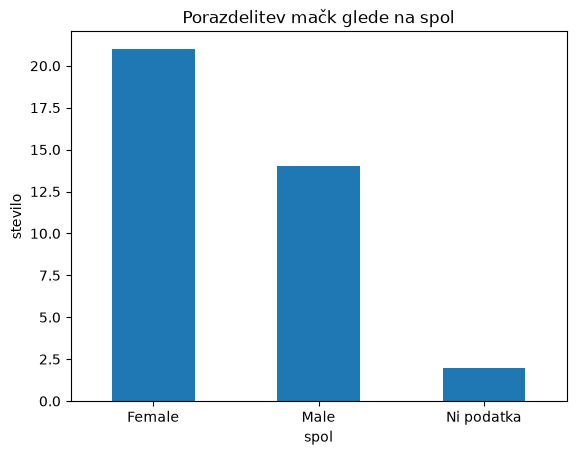

In [86]:
stevilo = df["spol"].fillna("Ni podatka").value_counts()
stevilo.plot(kind = "bar")
plt.title("Porazdelitev mačk glede na spol")
plt.xlabel("spol")
plt.ylabel("stevilo")
plt.xticks(rotation = 0)

V nadaljevanju nas bo zanimalo, koliko mačk je rezerviranih za posvojitev ("reserved") in koliko jih nanjo še čaka("available"). To bomo naredili na celotni populaciji ter za vsak spol posebej, nato pa izračunali deleže vsakega spola, ki so rezervirani.

In [87]:
st_je_na_voljo = (df["na voljo"] == "available").sum()
st_ni_na_voljo = (df["na voljo"] == "reserved").sum()
print(f"Za posvojitev: {st_je_na_voljo}, Rezerviranih: {st_ni_na_voljo}")

Za posvojitev: 23, Rezerviranih: 14


In [88]:
rezervirani_macki = df[(df["spol"] == "Male") & (df["na voljo"] == "reserved")]

In [89]:
rezervirani_macki.head()

,ime,na voljo,lokacija,starost,spol,pasma,posvojitev v paru,velikost,živi z otroki
26,Felix,reserved,Bedfordshire,63,Male,Domestic Shorthair,ne,Medium,da
27,Leaf,reserved,Bedfordshire,13,Male,Domestic Shorthair,ne,Medium,da
28,Tango,reserved,Berkshire,91,Male,Domestic Shorthair,ne,NaN,da
32,Toast,reserved,Cornwall,41,Male,Domestic Medium Hair,ne,Small,da
33,Kylo Ren,reserved,Bedfordshire,3,Male,Domestic Shorthair,ne,Medium,da


In [90]:
rezervirane_macke = df[(df["spol"] == "Female") & (df["na voljo"] == "reserved")]

In [91]:
rezervirane_macke.head()

,ime,na voljo,lokacija,starost,spol,pasma,posvojitev v paru,velikost,živi z otroki
23,Bosch,reserved,Berkshire,2,Female,NaN,ne,NaN,da
24,Makita,reserved,Berkshire,12,Female,Domestic Shorthair,ne,NaN,NaN
25,May,reserved,Berkshire,13,Female,Domestic Shorthair,ne,NaN,NaN
29,Jem,reserved,Berkshire,5,Female,Domestic Shorthair,da,NaN,NaN
30,Lucy,reserved,Berkshire,5,Female,Domestic Shorthair,da,NaN,da


In [92]:
stevilo_vseh_mackov = len(df[df["spol"] == "Male"])
stevilo_rezerviranih_mackov = len(rezervirani_macki)
stevilo_vseh_mack = len(df[df["spol"] == "Female"])
stevilo_rezerviranih_mack = len(rezervirane_macke)

In [93]:
delez_mackov = stevilo_rezerviranih_mackov/stevilo_vseh_mackov * 100
delez_mack = stevilo_rezerviranih_mack/stevilo_vseh_mack * 100
print(f"Delež rezerviranih mačkov: {delez_mackov:.2f} %, Delež rezerviranih mačk: {delez_mack:.2f} %")

Delež rezerviranih mačkov: 42.86 %, Delež rezerviranih mačk: 38.10 %


Text(0, 0.5, 'delež rezerviranih (%)')

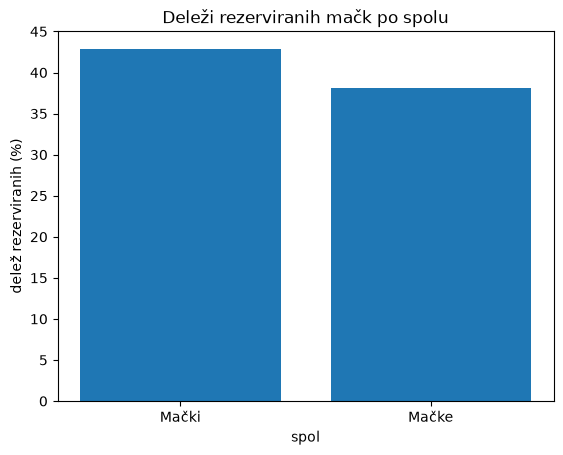

In [94]:
plt.bar(["Mački", "Mačke"], [delez_mackov, delez_mack])
plt.title("Deleži rezerviranih mačk po spolu")
plt.xlabel("spol")
plt.ylabel("delež rezerviranih (%)")

Iz grafa zaključimo, da imajo mački večjo možnost posvojitve kot mačke.

## Analiza mačk glede na starost

In [119]:
povprecna_starost_meseci = df["starost"].mean()
povprecna_starost_leta = povprecna_starost_meseci / 12
mediana_starosti_meseci = df["starost"].median()
mediana_starosti_leta = mediana_starosti_meseci / 12

print(f"Povprečna starost: {povprecna_starost_meseci:.2f} mesecev = {povprecna_starost_leta:.2f} let,"
      f"Mediana starosti: {mediana_starosti_meseci:.2f} mesecev = {mediana_starosti_leta:.2f} let")


Povprečna starost: 48.32 mesecev = 4.03 let,Mediana starosti: 37.00 mesecev = 3.08 let


V naslednjem koraku se bomo fokusirali na starostne skupine mačk. Podatke imamo podane v mesecih, mačja življenjska obdobja pa sem določila takole:
1: Mladički: do enega leta
2. "Najstniki": od prvega do šestega leta
3. Starejši mački: od šestega do desetega leta
4. Seniorji: starejše od deset let
Zanima nas razporeditev mačk iz zavetišč po danih starostnih skupinah, delež mačk, ki je v vsaki skupini dejansko rezerviran in pa podatek, kolikšen delež vseh mačk prihaja iz posamezne starostne skupine. V zavetiščih imajo starejše mačke in seniorji ponavadi veliko težav z iskanjem svojega novega doma. Veliko jih v oskrbi preživi veliko časa, še posebej po tem ko izgubijo svojega prejšnjega lastnika (in so zaradi tega bolj sramežljive in manj zaupljive), medtem ko imajo novi lastniki praviloma raje male razigrane mladičke kot pa starejše mačke.

Text(0.5, 1.0, 'Delež mačk po starostnih skupinah')

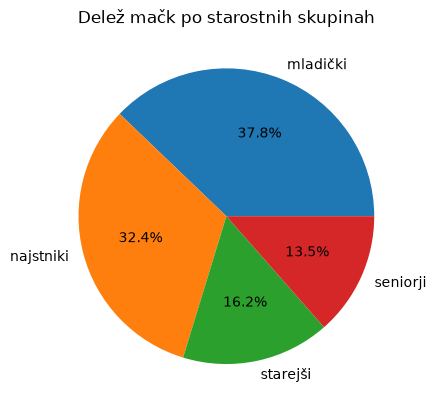

In [96]:
mladicki = df[df["starost"] < 13]
najstniki = df[(df["starost"] > 12) & (df["starost"] < 73)]
starejsi = df[(df["starost"] > 72) & (df["starost"] < 121)]
seniorji = df[df["starost"] > 120]
stevila = [len(mladicki), len(najstniki), len(starejsi), len(seniorji)]
starostne_skupine = ["mladički", "najstniki", "starejši", "seniorji"]

plt.pie(stevila, labels = starostne_skupine, autopct="%1.1f%%")
plt.title("Delež mačk po starostnih skupinah")

Graf nam nazorno pokaže, da so seniorji najmanj zastopani, največ pa je ravno mladičkov (sklepamo lahko, da je to posledica ravno vrhunca sezone parjenja).

In [97]:
rezerviranost_mladickov = mladicki[mladicki["na voljo"] == "reserved"]
delez_mladickov = len(rezerviranost_mladickov) / len(mladicki) * 100

In [98]:
rezerviranost_najstnikov = najstniki[najstniki["na voljo"] == "reserved"]
delez_najstnikov = len(rezerviranost_najstnikov) / len(najstniki) * 100

In [99]:
rezerviranost_starejsih = starejsi[starejsi["na voljo"] == "reserved"]
delez_starejsih = len(rezerviranost_starejsih) / len(starejsi) * 100

In [100]:
rezerviranost_seniorjev = seniorji[seniorji["na voljo"] == "reserved"]
delez_seniorjev = len(rezerviranost_seniorjev) / len(seniorji) * 100

Text(0, 0.5, ' delež rezerviranih (%)')

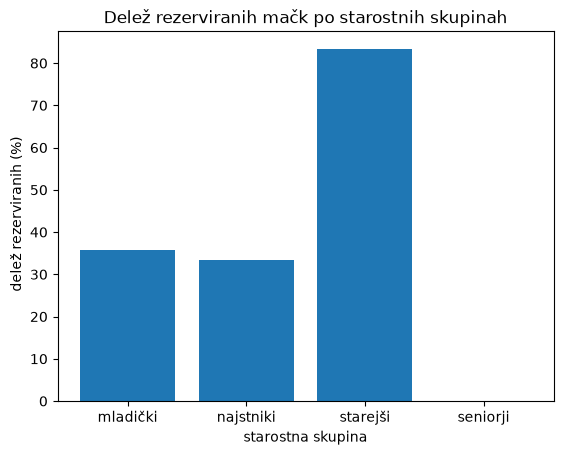

In [101]:
plt.bar(starostne_skupine, [delez_mladickov, delez_najstnikov, delez_starejsih, delez_seniorjev])
plt.title("Delež rezerviranih mačk po starostnih skupinah")
plt.xlabel("starostna skupina")
plt.ylabel(" delež rezerviranih (%)")

Moja prvotna hipoteza tu malce propade. Mladički namreč nimajo največjega deleža rezerviranih mačk, ampak so to ravno starejše mačke, kar se mi zdi presenetljivo. Na žalost pa zares lahko vidimo, da je seniorjem, torej mačkam v svojih zadnjih letih življenja, težje najti novega lastnika. 

Text(0.5, 1.0, 'Porazdelitev starostnih skupin med rezerviranimi mačkami')

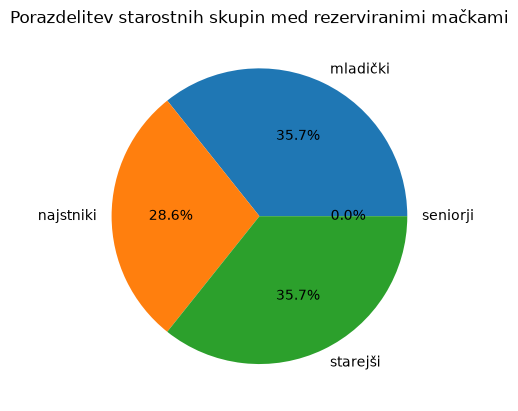

In [102]:
stevilo = [len(rezerviranost_mladickov), len(rezerviranost_najstnikov), len(rezerviranost_starejsih), len(rezerviranost_seniorjev)]

plt.pie(stevilo, labels=starostne_skupine, autopct="%1.1f%%")
plt.title("Porazdelitev starostnih skupin med rezerviranimi mačkami")

Do podobnega zaključka pridemo tudi s tem grafom, kjer seveda spet posvojen ni niti en senior. Analiziramo prav vse rezervirane mačke, ne glede na delež, ki ga te predstavljajo v vseh zavetiščih skupaj.

## Analiza zavetišč

Najprej nas zanima, koliko mačk je v vsakem od zavetišč.

In [103]:
polna_zavetisca = df.groupby("lokacija").size().sort_values(ascending=False).head(10)
polna_zavetisca.head()

lokacija
Hertfordshire    14
Berkshire         8
Cornwall          8
Bedfordshire      7
dtype: int64

<Axes: xlabel='lokacija'>

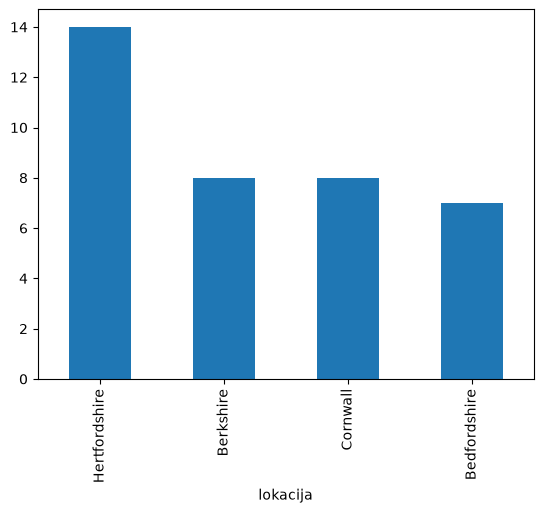

In [104]:
polna_zavetisca.plot.bar()

In [105]:
df.groupby(["lokacija", "velikost"]).size().sort_values(ascending=False)


lokacija      velikost
Bedfordshire  Medium      7
Cornwall      Medium      7
              Small       1
dtype: int64

Na začetku smo videli, da je velikost pogosto manjkajoča lastnost pri mačkah. Radi bi si ogledali, katero zavetišče je tisto, ki najbolj zgledno podaja velikosti mačk.To izračunamo tako, da za vsako lokacijo preverimo, kolikokrat se pri njej pojavi podatek za velikost in to delimo z številom vseh mačk v zavetišču.

In [106]:
delezi_velikosti = df.groupby("lokacija")["velikost"].count() / df.groupby("lokacija").size() * 100 
max_delezi = delezi_velikosti.max()
delezi_velikosti[max_delezi == delezi_velikosti]

lokacija
Bedfordshire    100.0
Cornwall        100.0
dtype: float64

### Ali je delež mačk, ki jih je mogoče posvojiti v paru, odvisen od starosti?

Zanima nas, če obstaja vzorec, preko katerega lahko razumemo, mačke katerih letih so najraje posvojene v parih.

In [107]:
df["leta"] = df["starost"] // 12
df["v_paru"] = df["posvojitev v paru"] == "da"
df.head()

,ime,na voljo,lokacija,starost,spol,pasma,posvojitev v paru,velikost,živi z otroki,leta,v_paru
0,Socks,available,Cornwall,52,Male,Domestic Shorthair,ne,Medium,da,4,False
1,Teddy,available,Cornwall,184,Male,Russian White,ne,Medium,ne,15,False
2,Ryobi,available,Berkshire,2,Female,NaN,ne,NaN,da,0,False
3,Stanley,available,Berkshire,2,Male,NaN,ne,NaN,da,0,False
4,Ivy,available,Hertfordshire,50,Female,Domestic Shorthair,ne,NaN,NaN,4,False


In [108]:
delez_v_paru = df.groupby("leta")["v_paru"].mean() * 100
print(delez_v_paru)

leta
0      69.230769
1       0.000000
2       0.000000
3      50.000000
4       0.000000
5       0.000000
6       0.000000
7      50.000000
8       0.000000
11    100.000000
12      0.000000
13    100.000000
15      0.000000
Name: v_paru, dtype: float64


<Axes: title={'center': 'Razporeditev posvojitve mačk v paru glede na leta'}, xlabel='leta'>

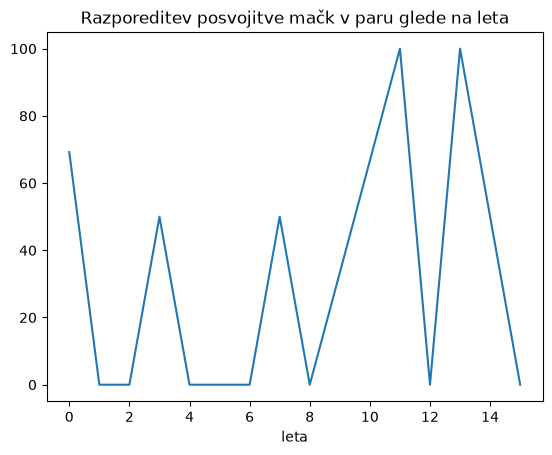

In [109]:
delez_v_paru.plot.line(title= "Razporeditev posvojitve mačk v paru glede na leta")


Zaradi majhnega vzorca so podatki razpršeni in ne sledijo nobenemu vzorcu.

In [110]:
naj_pasme = df.groupby("pasma").size().sort_values(ascending=False).head(10)
naj_pasme.info()

<class 'pandas.Series'>
Index: 4 entries, Domestic Shorthair to Russian White
Series name: None
Non-Null Count  Dtype
--------------  -----
4 non-null      int64
dtypes: int64(1)
memory usage: 64.0+ bytes


In [111]:
df["ima_pasmo"] = df["pasma"].notna()
df.head()

,ime,na voljo,lokacija,starost,spol,pasma,posvojitev v paru,velikost,živi z otroki,leta,v_paru,ima_pasmo
0,Socks,available,Cornwall,52,Male,Domestic Shorthair,ne,Medium,da,4,False,True
1,Teddy,available,Cornwall,184,Male,Russian White,ne,Medium,ne,15,False,True
2,Ryobi,available,Berkshire,2,Female,NaN,ne,NaN,da,0,False,False
3,Stanley,available,Berkshire,2,Male,NaN,ne,NaN,da,0,False,False
4,Ivy,available,Hertfordshire,50,Female,Domestic Shorthair,ne,NaN,NaN,4,False,True


In [112]:
delez_pasme = df.groupby("lokacija")["ima_pasmo"].mean() * 100
print(delez_pasme)

lokacija
Bedfordshire     100.000000
Berkshire         62.500000
Cornwall         100.000000
Hertfordshire     85.714286
Name: ima_pasmo, dtype: float64


### Kako je posvojitev v paru odvisna od starosti?

In [113]:
mladicki_par = mladicki[mladicki["posvojitev v paru"] == "da"]
najstniki_par = najstniki[najstniki["posvojitev v paru"] == "da"]
starejsi_par = starejsi[starejsi["posvojitev v paru"] == "da"]
seniorji_par = seniorji[seniorji["posvojitev v paru"] == "da"]

delez_par_mladicki = len(mladicki_par) / len(mladicki) * 100
delez_par_najstniki = len(najstniki_par) / len(najstniki) * 100
delez_par_starejsi = len(starejsi_par) / len(starejsi) * 100
delez_par_seniorji = len(seniorji_par) / len(seniorji) * 100

(0.0, 100.0)

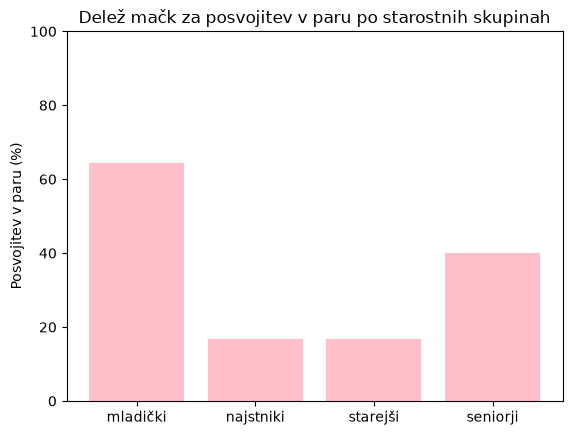

In [114]:
vrednosti = [delez_par_mladicki, delez_par_najstniki, delez_par_starejsi, delez_par_seniorji]

plt.bar(starostne_skupine, vrednosti, color="pink")
plt.title("Delež mačk za posvojitev v paru po starostnih skupinah")
plt.ylabel("Posvojitev v paru (%)")
plt.ylim(0, 100)

Mladički se glede na naše izračune najraje pridružijo še svojemu prijatelju. Seniorji so veliko bolj dovzetni za druženje kot prvotna napoved.

Zanima nas tudi, kako se spreminja delež posvojitve mladičkov v paru glede na njihovo starost (torej spreminjanje glede na prvih 12 mesecev).

(0.0, 100.0)

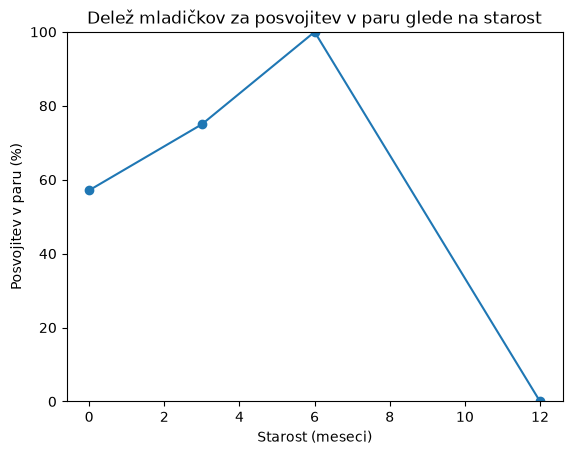

In [115]:
mladicki["meseci_razred"] = mladicki["starost"] // 3 * 3
mladicki["v_paru"] = mladicki["posvojitev v paru"] == "da"

delez = mladicki.groupby("meseci_razred")["v_paru"].mean() * 100

delez.plot.line(marker="o")
plt.title("Delež mladičkov za posvojitev v paru glede na starost")
plt.xlabel("Starost (meseci)")
plt.ylabel("Posvojitev v paru (%)")
plt.ylim(0, 100)

Majhni mladički do šestih mesecev se najraje posvojijo v paru, pri 6 mesecih je vrh.

## Analiza pasem

"Domestic shorthair" je najpogostejša mačja pasma, ki nikoli ni bila posebej estetsko rejena in namenjena za prodajo po visoki ceni. Te živali so tiste, ki najpogosteje pristanejo na cesti, pod avti in v zavetiščih, zato tudi najbolj pogosto iščejo dom. Vseeno me je pri razsikavi zanimalo, kakšna je pogostost ostalih bolj prestižnih pasem in kako je z njihovimi posvojitvami. Ker je njihovo število tako majhno, jih je bilo smiselno vse združiti pod eno kategorijo. 

In [116]:
domestic_shorthair = df[df["pasma"] == "Domestic Shorthair"]
ostale = df[(df["pasma"] != "Domestic Shorthair") & (df["pasma"].notna())]
ni_podatka = df["pasma"].isnull()
print(f"Pojavitve domače pasme: {len(domestic_shorthair)}, Pojavitve vseh ostalih pasem: {len(ostale)}, Ni podatka: {ni_podatka.sum()}")

Pojavitve domače pasme: 29, Pojavitve vseh ostalih pasem: 3, Ni podatka: 5


Text(0.5, 1.0, 'Deleži pasem')

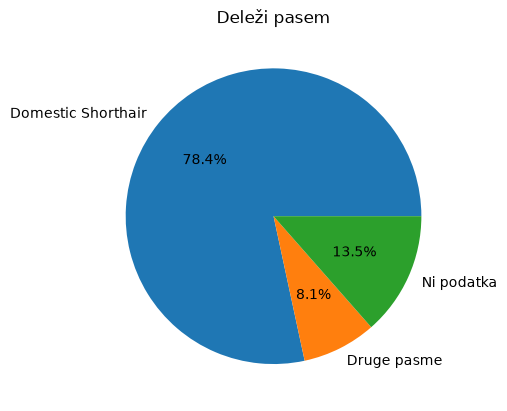

In [117]:
stevilo_dom_sh = len(domestic_shorthair)
ostale_pasme = len(ostale)
st_ni_podatka = ni_podatka.sum()

plt.pie([stevilo_dom_sh, ostale_pasme, st_ni_podatka], labels=["Domestic Shorthair", "Druge pasme", "Ni podatka"], autopct="%1.1f%%")
plt.title("Deleži pasem")

Delež rezerviranih domačih: 41.38, Delež rezerviranih ostalih: 33.33


(0.0, 100.0)

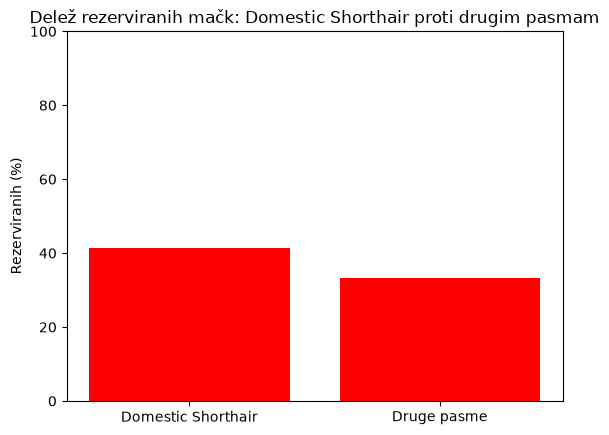

In [118]:
delez_domestic_shorthair =  (domestic_shorthair["na voljo"] == "reserved").mean() * 100
delez_ostale = (ostale["na voljo"] == "reserved").mean() * 100
print(f"Delež rezerviranih domačih: {delez_domestic_shorthair:.2f}, Delež rezerviranih ostalih: {delez_ostale:.2f}")

plt.bar(["Domestic Shorthair", "Druge pasme"], [delez_domestic_shorthair, delez_ostale], color = 'red')
plt.title("Delež rezerviranih mačk: Domestic Shorthair proti drugim pasmam")
plt.ylabel("Rezerviranih (%)")
plt.ylim(0, 100)

Predvidela sem, da bo odstotek rezerviranosti drugih, bolj eksotičnih pasem večji, vendar nam analiza vrne ravno nasprotno, torej da imajo domače mačke v izbranih zavetiščih dejansko večjo možnost, da so posvojene kot druge pasme. Zaradi res majhnega nabora mačkov drugih pasem, pa je tudi ta del analize malce manj verodostojen.

## Zaključek

Vzorec je seveda precej majhen, ampak je bilo vseeno možno priti do konkretnih ugovotitev:
1. Mladički v splošnem nimajo večjih možnosti za posvojitev kot druge starostne skupine.
2. Seniorji so zares na zadnjem mestu za posvojitev, so pa starejše mačke zelo rezervirane.
3. Ljudje, ki mačke iščejo v zavetiščih, v resnici nimajo preferenc za posebnejše mačke.
4. Od vseh starostnih skupin, se mladički res najraje posvajajo v paru.  